### Introduction


This notebook demonstrates how data is collected from external sources, cleaned, merged, and stored in AWS S3. It also includes a brief exploratory data analysis to help determine which features to use in modeling. If your focus is mainly on model building, you can skip this notebook and go directly to the modeling notebook.

In [5]:
# manipulation
import pandas as pd
from src.data.preprocessing import set_datetime_index, extract_date_column

# plotting
import matplotlib.pyplot as plt
from skforecast.plot import set_dark_theme

# sources
from src.data.sources import EpiasClient, OpenMeteoClient, Location

# storage
from src.data.storage import S3Bucket, S3DatasetStore, GlueCatalog

### Electricity Consumption  
Electricity consumption data is retrieved from the [EPİAŞ Transparency Platform](https://seffaflik.epias.com.tr), which publishes Turkey’s energy market data. The unofficial [eptr2](https://github.com/Tideseed/eptr2) package on GitHub provides broad coverage of the platform’s API if you would like to explore beyond what is implemented in this project.

In [2]:
# client that handles EPİAŞ authentication and 
# provides methods to fetch relevant endpoints

epias_client = EpiasClient.from_env(
    username_var="EPIAS_USERNAME",
    password_var="EPIAS_PASSWORD",
)

In [3]:
# fetch hourly (realtime) electricity consumption
# from EPİAŞ for the given date range

start_date = "2026-01-01"
end_date   = "2026-01-31"

response = epias_client.get_realtime_consumption(start_date, end_date)
cons_raw = response.df()
cons_raw.head()

,date,time,consumption
0,2026-01-01T00:00:00+03:00,00:00,34416.38
1,2026-01-01T01:00:00+03:00,01:00,32741.81
2,2026-01-01T02:00:00+03:00,02:00,31112.69
3,2026-01-01T03:00:00+03:00,03:00,29841.44
4,2026-01-01T04:00:00+03:00,04:00,29162.98


In the raw DataFrame, the `date` column arrives as a string. It is converted to datetime using `pd.to_datetime()` and set as index, also `time` column can be dropped because it only contains the hour, which can be derived directly from `datetime` whenever needed. This leaves us with a clean, indexed time series.


In [4]:
# set datetime index
cons_transformed = set_datetime_index(
    cons_raw,
    column="date",
    drop_tz_info=True,
    index_name="datetime",
)

# drop unnecessary column
cons_transformed = cons_transformed.drop(columns=["time"], errors="ignore")

cons_transformed

,consumption
datetime,
2026-01-01 00:00:00,34416.38
2026-01-01 01:00:00,32741.81
2026-01-01 02:00:00,31112.69
2026-01-01 03:00:00,29841.44
2026-01-01 04:00:00,29162.98
...,...
2026-01-31 19:00:00,44899.17
2026-01-31 20:00:00,43592.05
2026-01-31 21:00:00,42328.38


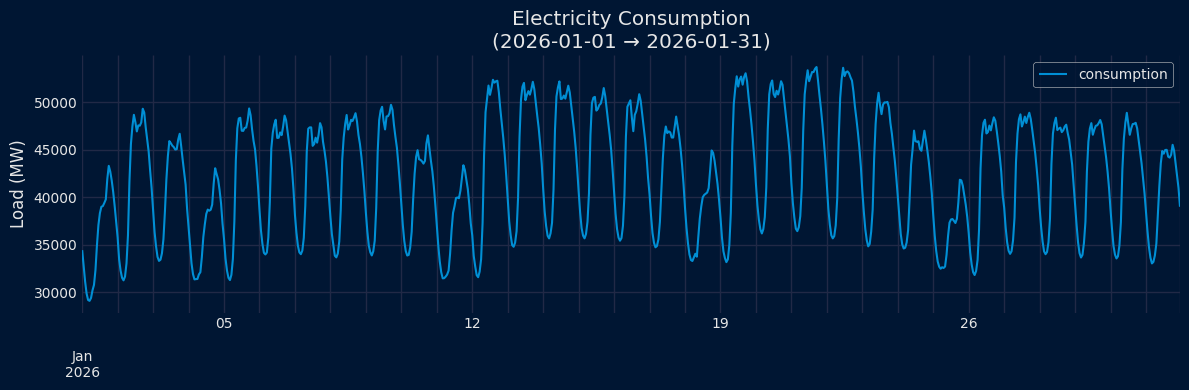

In [5]:
set_dark_theme()

# plot the hourly consumption time series
cons_transformed.plot(
    figsize=(12, 4), 
    title=f"Electricity Consumption\n({start_date} → {end_date})",
    xlabel="",
    ylabel="Load (MW)",
)

plt.tight_layout()

### Consumption Ratio by Province

EPİAŞ also provides monthly province-level percentage consumption data which will become handy when determining weather features in the next section.


In [6]:
# fetch percentage electricity consumption
# info from EPİAŞ for the given date range.

# list of months between 2023-01 and 2025-12
months = pd.date_range("2023-01", "2025-12", freq='MS')

dfs = []
for m in months:
    # fetch for each month in given interval
    df = epias_client.get_percentage_consumption_info(m).df()
    # extract usefull data from the response dataframe
    df = df[["province","consumptionRatioBasedOnProvince"]]
    dfs.append(df)
        

# combine monthly dataframes and compute
# the average ratio per province.
percentage_info = (
    pd.concat(dfs)
      .groupby("province", as_index=False)
      .mean()
)

# Result
percentage_info

,province,consumptionRatioBasedOnProvince
0,ADANA,2.869706
1,ADIYAMAN,0.627778
2,AFYONKARAHİSAR,1.026111
3,AKSARAY,0.593125
4,AMASYA,0.324545
...,...,...
77,İSTANBUL-ASYA,7.131714
78,İSTANBUL-AVRUPA,15.151667
79,İZMİR,7.061944
80,ŞANLIURFA,2.492222


This output confirms that we have coverage for Turkey’s full set of provinces: 81 provinces in total, with İstanbul represented as two separate entries (*İSTANBUL-ASYA* and *İSTANBUL-AVRUPA*). Each row gives the province and its corresponding contribution value. Next, we can sort the provinces by descending order to see which regions contribute the most.


In [10]:
percentage_info_sorted = percentage_info.sort_values("consumptionRatioBasedOnProvince", ascending=False, ignore_index=True)
percentage_info_top_10 = percentage_info_sorted.head(10)
percentage_info_top_10

,province,consumptionRatioBasedOnProvince
52,YOZGAT,0.445278
53,KARAMAN,0.432188
54,RİZE,0.419444
55,ŞIRNAK,0.414444
56,GİRESUN,0.405000
57,BURDUR,0.333611
58,AMASYA,0.324545
59,KIRIKKALE,0.315000
60,BİTLİS,0.279444
61,SİİRT,0.278889


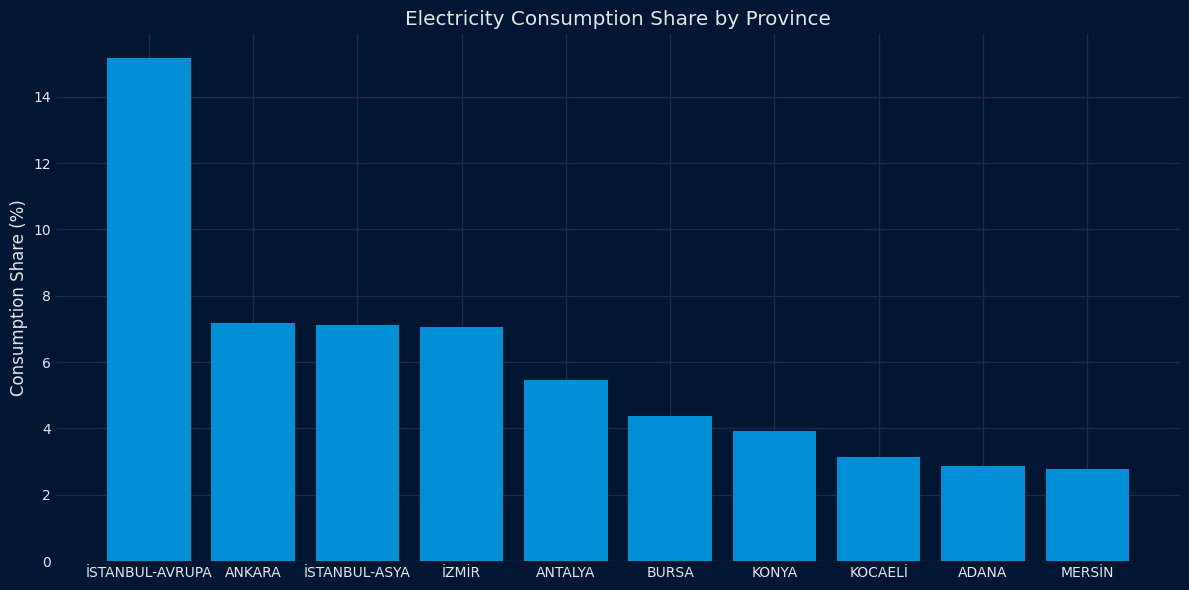

In [10]:
# Plot top contributors

plt.figure(figsize=(12, 6))
plt.bar(
    percentage_info_top_10["province"],
    percentage_info_top_10["consumptionRatioBasedOnProvince"]
)
plt.ylabel("Consumption Share (%)")
plt.title("Electricity Consumption Share by Province")
plt.tight_layout()

As expected, İstanbul (European and Asian sides combined) accounts for a disproportionately large share of Turkey’s national electricity consumption.



### Temperature

Temperature data is retrieved from the [Open-Meteo](https://open-meteo.com) API, which is a free and open-source weather data service providing historical and forecast meteorological data.

In [12]:
# client that provides methods for fetching
# historical and forecasted temperature data

openmeteo_client = OpenMeteoClient()

Before fetching weather data, the locations for which temperature information will be retrieved must be specified. This is done by creating instances of the `Location` class, where each instance is defined by locations name, latitude and longitude.

In [13]:
# locations for the top 5 provinces.
locations = [
    Location("istanbul", 41.0082, 28.9784),
    Location("ankara",   39.9334, 32.8597),
    Location("izmir",    38.4237, 27.1428),
    Location("antalya",  36.8969, 30.7133),
    Location("bursa",    40.1950, 29.0600)
]

In [16]:
# fetch hourly 2 m temperature from Open-Meteo
# for the given date range and locations.

responses = openmeteo_client.get_temperature(start_date, end_date, locations)
temps_raw = [resp.df() for resp in responses]
temps_raw[0] # <-- first location

,time,temperature_2m
0,2026-01-01T00:00,-0.9
1,2026-01-01T01:00,-1.3
2,2026-01-01T02:00,-1.1
3,2026-01-01T03:00,-0.6
4,2026-01-01T04:00,-0.6
...,...,...
739,2026-01-31T19:00,6.6
740,2026-01-31T20:00,6.2
741,2026-01-31T21:00,5.8
742,2026-01-31T22:00,5.7


Unlike consumption, weather data is returned as multiple DataFrames because it is requested for several locations. However, the transformation steps are similar to those used for consumption: we convert the `time` column to `datetime` using `pd.to_datetime()`, then set it as index. One additional step is to include the location name in the column names (e.g., `temp_istanbul`, `temp_ankara`) to ensure columns remain unique when combining DataFrames.



In [27]:
temps_transformed = []
for raw, loc in zip(temps_raw, locations):
    # Set datetime index
    transformed = set_datetime_index(
        raw,
        column="time",
        index_name="datetime"
    )
    # Rename temperature column for location
    transformed = transformed.rename(columns={"temperature_2m": f"{loc.name}_temp"})

    temps_transformed.append(transformed)

# Concatenate all location temperature series on the datetime index.
temps_transformed_wide = pd.concat(temps_transformed, join='inner', axis=1)
temps_transformed_wide.head()

,istanbul_temp,ankara_temp,izmir_temp,antalya_temp,bursa_temp
datetime,,,,,
2026-01-01 00:00:00,-0.9,-3.2,1.7,6.8,-5.5
2026-01-01 01:00:00,-1.3,-3.7,1.1,6.3,-5.4
2026-01-01 02:00:00,-1.1,-3.8,0.7,5.6,-5.5
2026-01-01 03:00:00,-0.6,-4.2,0.1,6.1,-6.0
2026-01-01 04:00:00,-0.6,-4.2,-0.1,6.1,-6.1


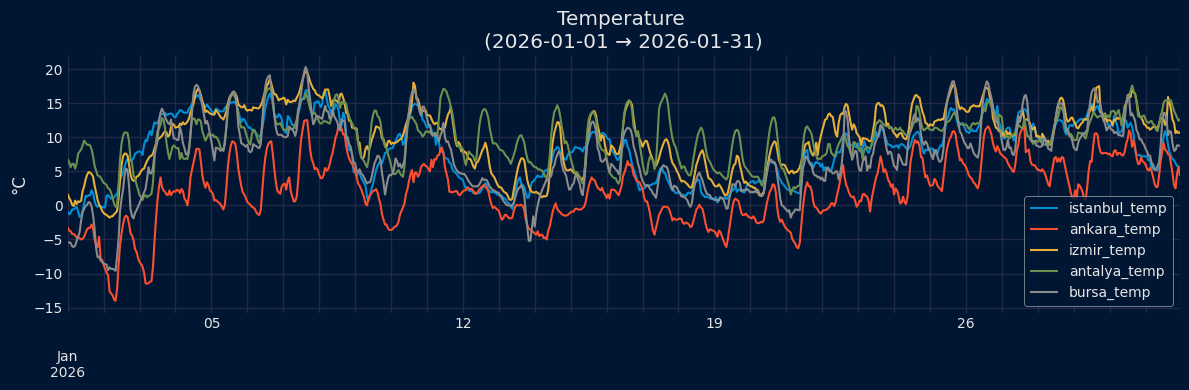

In [21]:
# plot the temperature time series
temps_transformed_wide.plot(
    figsize=(12, 4), 
    title=f"Temperature \n({start_date} → {end_date})",
    xlabel="",
    ylabel="°C",
)

plt.tight_layout()

### Storage

The final transformed DataFrames for both consumption and temperature can be persisted to cloud storage to enable reuse by downstream workflows. [Amazon S3](https://aws.amazon.com/s3/) is used as the storage layer. Before writing, the two cleaned hourly time-series tables, `cons_transformed` and `temps_transformed_wide` are combined into a single feature dataset by joining them on their shared hourly timestamp, `datetime`.

After building the combined table, a `date` column is derived from the timestamp index. This column is used only for partitioning when writing to S3 (Hive-style partitions such as `date=2026-01-01/`). Partitioning ensures efficient queries, allowing downstream workflows to load only the relevant date ranges without scanning the entire dataset.

In [26]:
# join transformed dataframes and
transformed = cons_transformed.join(
    temps_transformed_wide,
    how="left",
    validate="1:1"
)

# derive a date column for partitioning
transformed = extract_date_column(transformed, column_name="date")
transformed.head()

,consumption,istanbul_temp,ankara_temp,izmir_temp,antalya_temp,bursa_temp,date
datetime,,,,,,,
2026-01-01 00:00:00,34416.38,-0.9,-3.2,1.7,6.8,-5.5,2026-01-01
2026-01-01 01:00:00,32741.81,-1.3,-3.7,1.1,6.3,-5.4,2026-01-01
2026-01-01 02:00:00,31112.69,-1.1,-3.8,0.7,5.6,-5.5,2026-01-01
2026-01-01 03:00:00,29841.44,-0.6,-4.2,0.1,6.1,-6.0,2026-01-01
2026-01-01 04:00:00,29162.98,-0.6,-4.2,-0.1,6.1,-6.1,2026-01-01


With the help of the [awswrangler](https://github.com/aws/aws-sdk-pandas) package, working with S3 datasets becomes much more ergonomic: it can read a dataset by automatically discovering and concatenating partitioned files into a single DataFrame.

In [28]:
# define the S3 bucket that will hold
# the datasets, models and reports
bucket = S3Bucket("ts-forecast-boramkesil")

# optional glue catalog
catalog = GlueCatalog(
    database="ts-forecast",
    table="tr_consumption_temperature_hourly"
)

# configure a dataset store in S3 
# for the hourly feature table
dataset_store = S3DatasetStore(
    prefix="tr_consumption_temperature_hourly",
    mode="overwrite_partitions",
    partition_columns=["date"],
    glue_catalog=catalog
)

In [27]:
# write the merged hourly feature table 
# to S3 using the configured DatasetStore.
dataset_store.write_partitioned(
    df=transformed,
    s3_bucket=bucket,
    index=True, # <-- include index as a column when writing
)

We can see that all daily partitions between `start_date` and `end_date` have been written to the S3 bucket.

![S3 partitioned layout](images/dataset_store.png)

At this point, retrieving, transforming, and storing the consumption and temperature data in S3 has been completed. The next notebook will implement the forecasting model.